# `holodeck` - librarian

Module for generating and managing simulation libraries.  Holodeck libraries are groups of simulations in which certain parameters are varied, for example parameters concerning the masses of black holes (e.g. through the M-Mbulge relationship), or parameters dictating the rate of binary evolution.  For more information, see the [holodeck getting started guide](https://holodeck-gw.readthedocs.io/en/main/getting_started/index.html), and specifically the page on [holodeck libraries](https://holodeck-gw.readthedocs.io/en/main/getting_started/libraries.html).

Currently, libraries are only implemented from semi-analytic models (SAMs), which use the [`holodeck.sams.sam.Semi_Analytic_Model`](https://holodeck-gw.readthedocs.io/en/main/api_ref/holodeck.sams.html) class.  And binary evolution ('hardening') models implemented as subclasses of [`holodeck.hardening._Hardening`](https://holodeck-gw.readthedocs.io/en/main/api_ref/holodeck.hardening.html).

In [1]:
%reload_ext autoreload
%autoreload

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import kalepy as kale

# --- Holodeck ----
import holodeck as holo
import holodeck.librarian
import holodeck.librarian.param_spaces
from holodeck import cosmo, utils, plot

log = holo.log
log.setLevel(log.WARNING)

## Parameter spaces – `_Param_Space` subclasses

Holodeck libraries are build around their parameter-spaces, which are implemented as subclasses of the [`holodeck.librarian.lib_tools._Param_Space`](https://holodeck-gw.readthedocs.io/en/main/api_ref/holodeck.librarian.lib_tools.html#holodeck.librarian.lib_tools._Param_Space) base class.  These subclasses should be named with `PS_` prefixes to denote that they are parameter spaces.

In [2]:
PSPACE_CLASS = holo.librarian.param_spaces_dict['PS_Astro_Strong_Covariant_GSMF']   # or PS_Test_Astro_Strong_Covariant_MMBulge ## #: Choose which parameter-space class to use
NSAMPLES = 10000    #: Number of samples to draw
SAM_SHAPE = (20, 21, 22)   #: Shape of the semi-analytic model grid (in the `Semi_Analytic_Model` class)

In [3]:
print(holo.librarian.param_spaces_dict)

{'PS_Classic_Test': <class 'holodeck.librarian.param_spaces_classic.PS_Classic_Test'>, 'PS_Classic_Phenom_Uniform': <class 'holodeck.librarian.param_spaces_classic.PS_Classic_Phenom_Uniform'>, 'PS_Classic_Phenom_Astro_Extended': <class 'holodeck.librarian.param_spaces_classic.PS_Classic_Phenom_Astro_Extended'>, 'PS_Classic_GWOnly_Uniform': <class 'holodeck.librarian.param_spaces_classic.PS_Classic_GWOnly_Uniform'>, 'PS_Classic_GWOnly_Astro_Extended': <class 'holodeck.librarian.param_spaces_classic.PS_Classic_GWOnly_Astro_Extended'>, 'PS_Test': <class 'holodeck.librarian.param_spaces.PS_Test'>, 'PS_Astro_Strong_All': <class 'holodeck.librarian.param_spaces.PS_Astro_Strong_All'>, 'PS_Astro_Strong_Hard': <class 'holodeck.librarian.param_spaces.PS_Astro_Strong_Hard'>, 'PS_Astro_Strong_Hard_All': <class 'holodeck.librarian.param_spaces.PS_Astro_Strong_Hard_All'>, 'PS_Astro_Strong_GSMF': <class 'holodeck.librarian.param_spaces.PS_Astro_Strong_GSMF'>, 'PS_Astro_Strong_GMR': <class 'holodeck.l

In [5]:
# construct an instance of the parameter-space class, which draws samples from the parameter space
# using a latin hypercube
pspace = PSPACE_CLASS(holo.log, nsamples=NSAMPLES, sam_shape=SAM_SHAPE)
print(f"pspace '{pspace.name}'")
print(f"\tlibrary shape={pspace.lib_shape} (samples, parameters)")
print(f"\tSAM grid shape={pspace.sam_shape}")
print(f"\tparameters ({pspace.nparameters}):")
extr = pspace.extrema
i = 0 
for dist in pspace._parameters:
    n_dims = dist.n_params if dist.n_params is not None else 1
    current_extr = extr[i : i + n_dims, :]
    dist_name = dist.__class__.__name__
    if n_dims == 1:
        pp_name = dist.name
        print(f"\t\t{pp_name} (Dist:{dist_name}): [{current_extr[0, 0]:.3g}, {current_extr[0, 1]:.3g}]")
    else:
        pp_names = dist.name # This is the list/tuple of names
        print(f"\t\t{pp_names} (Dist:{dist_name}, Coupled {n_dims}D):")
        for k in range(n_dims):
            name = pp_names[k]
            min_val = current_extr[k, 0]
            max_val = current_extr[k, 1]
            print(f"\t\t\t> {name}: [{min_val:.3g}, {max_val:.3g}]")
    i += n_dims


pspace 'PS_Astro_Strong_Covariant_GSMF'
	library shape=(10000, 11) (samples, parameters)
	SAM grid shape=(20, 21, 22)
	parameters (11):
		('gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2', 'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2', 'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2', 'gsmf_alpha_one', 'gsmf_alpha_two') (Dist:PD_MVNormal, Coupled 11D):
			> gsmf_log10_phi_one_z0: [-inf, inf]
			> gsmf_log10_phi_one_z1: [-inf, inf]
			> gsmf_log10_phi_one_z2: [-inf, inf]
			> gsmf_log10_phi_two_z0: [-inf, inf]
			> gsmf_log10_phi_two_z1: [-inf, inf]
			> gsmf_log10_phi_two_z2: [-inf, inf]
			> gsmf_log10_mstar_z0: [-inf, inf]
			> gsmf_log10_mstar_z1: [-inf, inf]
			> gsmf_log10_mstar_z2: [-inf, inf]
			> gsmf_alpha_one: [-inf, inf]
			> gsmf_alpha_two: [-inf, inf]


In [6]:
print(f"{pspace.param_names=}\n{pspace._param_dist_names=}\n{pspace._parameters=}")
print(pspace._parameters[0])
print(pspace.extrema)
#pspace._parameters[0].extrema
extr = pspace.extrema
i = 0 # Running index for slicing the extrema array
for dist in pspace._parameters:
    # 1. Get the number of parameters governed by this distribution (N_dims)
    n_dims = dist.n_params if dist.n_params is not None else 1
    # 2. Slice the bounds from the combined extrema array
    current_extr = extr[i : i + n_dims, :]

    # 3. Handle the output formatting
    dist_name = dist.__class__.__name__
    if n_dims == 1:
        # Univariate: Print the single name and the single 1D bounds array
        pp_name = dist.name
        print(f"\t\t{pp_name} (Dist:{dist_name}): [{current_extr[0, 0]:.3g}, {current_extr[0, 1]:.3g}]")
    else:
        # Multivariate: Print the coupled names and the individual 2D bounds
        pp_names = dist.name # This is the list/tuple of names
        print(f"\t\t{pp_names} (Dist:{dist_name}, Coupled {n_dims}D):")
        for k in range(n_dims):
            name = pp_names[k]
            min_val = current_extr[k, 0]
            max_val = current_extr[k, 1]
            print(f"\t\t\t> {name}: [{min_val:.3g}, {max_val:.3g}]")
    # 4. Advance the index for the next distribution
    i += n_dims


pspace.param_names=['gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2', 'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2', 'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2', 'gsmf_alpha_one', 'gsmf_alpha_two']
pspace._param_dist_names=[('gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2', 'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2', 'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2', 'gsmf_alpha_one', 'gsmf_alpha_two')]
pspace._parameters=[<holodeck.librarian.lib_tools.PD_MVNormal object at 0x1400c1090>]
[[-inf  inf]
 [-inf  inf]
 [-inf  inf]
 [-inf  inf]
 [-inf  inf]
 [-inf  inf]
 [-inf  inf]
 [-inf  inf]
 [-inf  inf]
 [-inf  inf]
 [-inf  inf]]
		('gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2', 'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2', 'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_m

Create a corner plot showing where the samples are in each 1D and 2D slice of the parameter space.

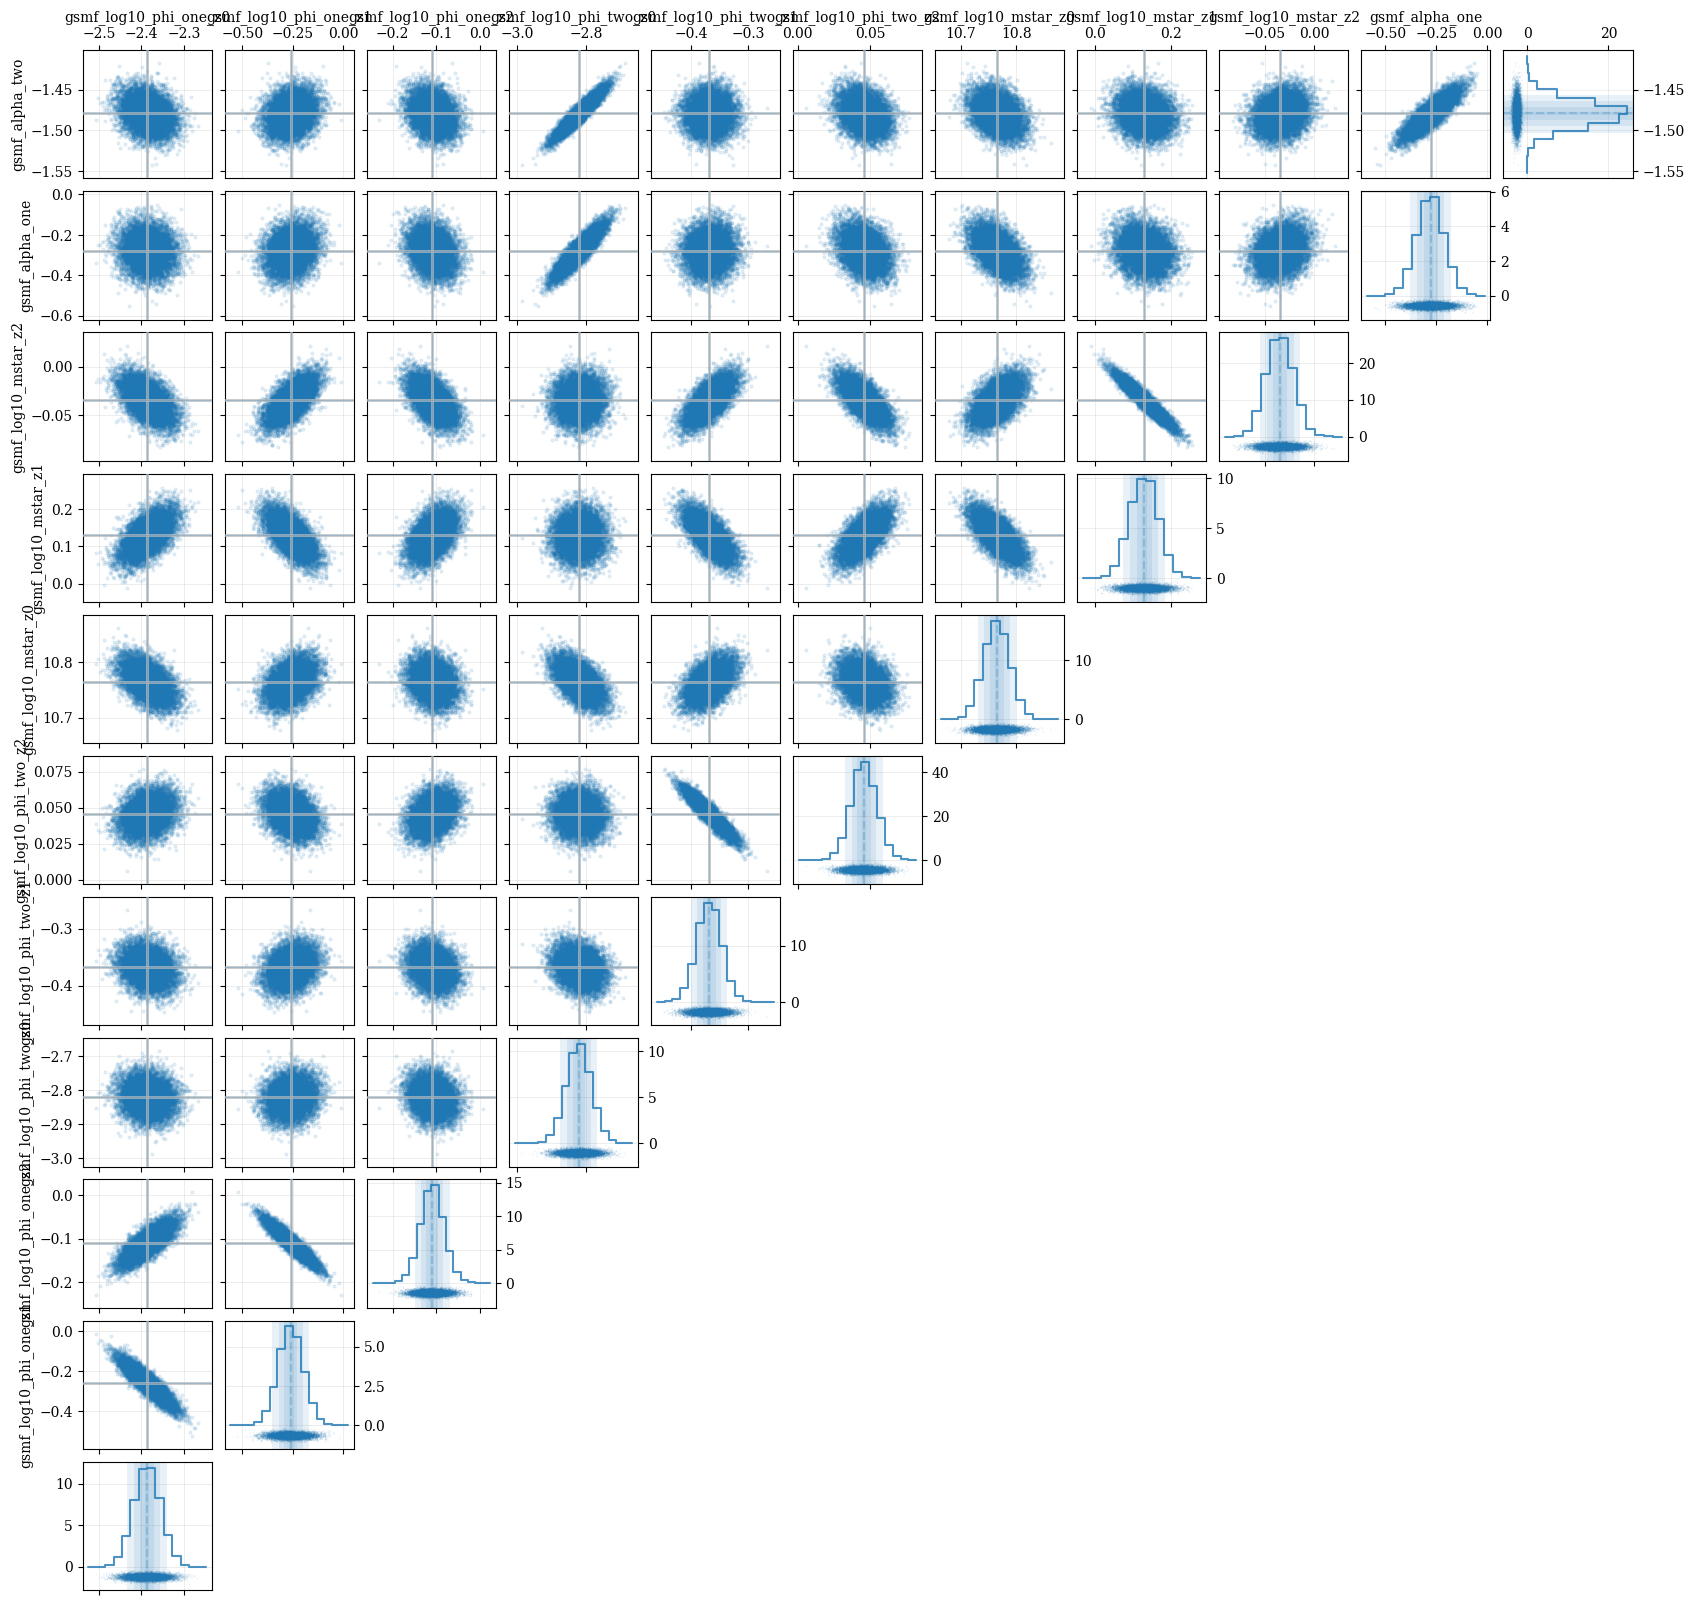

In [7]:
kale.corner(
    pspace.param_samples.T, labels=pspace.param_names,
    dist2d=dict(scatter=True, hist=False, contour=False),
    dist1d=dict(carpet=True, hist=True, density=False),
)
plt.show()

Build model instances (`sam` instance of `Semi_Analytic_Model` and `hard` instance of `_Hardening`)

In [8]:
# The sample parameters are stored as an array `param_samples`, which has a shape of `(S, P)` for
# `S` random samples and `P` parameters
SAMP = 4
print(f"Parameters for sample {SAMP}: {pspace.param_samples[SAMP]}")
# We can also obtain a dictionary of these parameters, with the parameter names as keys:
params = pspace.param_dict(SAMP)
for kk, vv in params.items():
    print(f"\t{kk:20s}: {vv:+.2e}")

# We can load `Semi_Analytic_Model` and `_Hardening` class instances for this in two ways:
# (1) by passing in this dictionary of parameters:
sam, hard = pspace.model_for_params(params)
# (2) by passing in the sample number
sam, hard = pspace.model_for_sample_number(SAMP)

Parameters for sample 4: [-2.43611657 -0.19649457 -0.11691639 -2.83305016 -0.34497707  0.03605763
 10.8006474   0.07903    -0.01980046 -0.29958503 -1.47889005]
	gsmf_log10_phi_one_z0: -2.44e+00
	gsmf_log10_phi_one_z1: -1.96e-01
	gsmf_log10_phi_one_z2: -1.17e-01
	gsmf_log10_phi_two_z0: -2.83e+00
	gsmf_log10_phi_two_z1: -3.45e-01
	gsmf_log10_phi_two_z2: +3.61e-02
	gsmf_log10_mstar_z0 : +1.08e+01
	gsmf_log10_mstar_z1 : +7.90e-02
	gsmf_log10_mstar_z2 : -1.98e-02
	gsmf_alpha_one      : -3.00e-01
	gsmf_alpha_two      : -1.48e+00


Run the model

In [9]:
data = holo.librarian.lib_tools.run_model(sam, hard, details_flag=True)
print(data.keys())
data['gwb']

21:14:54 ERROR : Warning, significant change in number-mass!  mass: 7.62e-01 ==> 1.05e+00 || change = 3.7901e-01 [sam.py:static_binary_density]
dict_keys(['fobs_cents', 'fobs_edges', 'static_binary_density', 'number', 'redz_final', 'gwb_params', 'num_params', 'gwb_mtot_redz_final', 'num_mtot_redz_final', 'hc_ss', 'hc_bg', 'gwb'])


array([[2.19109224e-15, 1.85770137e-15, 2.80342338e-15, ...,
        1.78054474e-15, 2.49870779e-15, 1.82814664e-15],
       [5.13992242e-15, 4.34924213e-15, 4.33861123e-15, ...,
        3.51102129e-15, 5.70591259e-15, 3.49746960e-15],
       [4.76069436e-15, 5.20041405e-15, 4.12611255e-15, ...,
        4.39484425e-15, 4.33543098e-15, 8.14516391e-15],
       ...,
       [4.89582625e-16, 8.15570297e-16, 6.16780246e-16, ...,
        8.60856369e-16, 4.32721542e-16, 9.30158491e-16],
       [5.21193410e-16, 4.37116076e-16, 5.71186309e-16, ...,
        6.79530084e-16, 4.85875642e-16, 4.50079483e-16],
       [1.99170970e-15, 5.71540251e-16, 7.03714621e-16, ...,
        4.25329395e-16, 7.79666460e-16, 4.64654214e-16]], shape=(40, 100))

### Custom class

21:33:53 ERROR : Warning, significant change in number-mass!  mass: 3.41e-01 ==> 6.10e-01 || change = 7.8895e-01 [sam.py:static_binary_density]


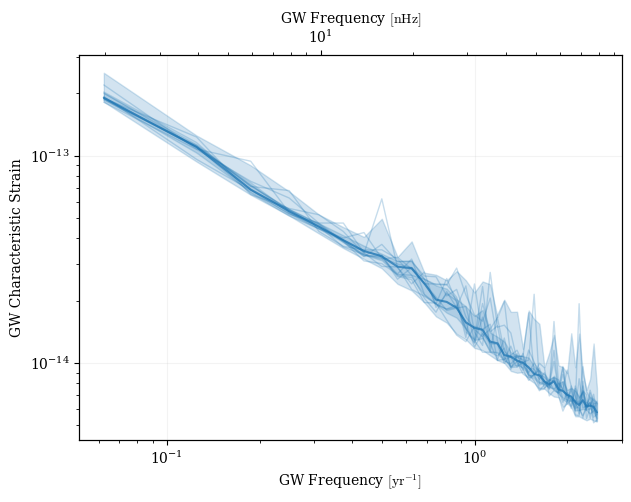

In [25]:
class PS_Lib_Test(holo.librarian.lib_tools._Param_Space):

    DEFAULTS = {'gsmf_phi0_log10': -2.77}

    def __init__(self, log, nsamples, sam_shape):
        parameters = [
            holo.librarian.lib_tools.PD_Normal("gsmf_phi0_log10", -2.77, 0.3),
        ]
        super().__init__(
            parameters,
            log=log, nsamples=nsamples, sam_shape=sam_shape,
        )
        return

    @classmethod
    def _init_sam(cls, sam_shape, params):
        gsmf = holo.sams.components.GSMF_Schechter(phi0=params['gsmf_phi0_log10'])
        sam = holo.sams.sam.Semi_Analytic_Model(gsmf=gsmf, shape=sam_shape)
        return sam

    @classmethod
    def _init_hard(cls, sam, params):
        hard = holo.hardening.Hard_GW()
        return hard

test = PS_Lib_Test(log, 4, 10)
fobs_cents, fobs_edges = utils.pta_freqs()
sam, hard = test.model_for_sample_number(0)
hc_ss, hc_bg = sam.gwb(fobs_edges, hard=hard, realize=20)
plot.plot_gwb(fobs_cents, hc_bg)
plt.show()

## Parameter distributions – `_Param_Dist` subclasses

### Uniform (`PD_Uniform`)

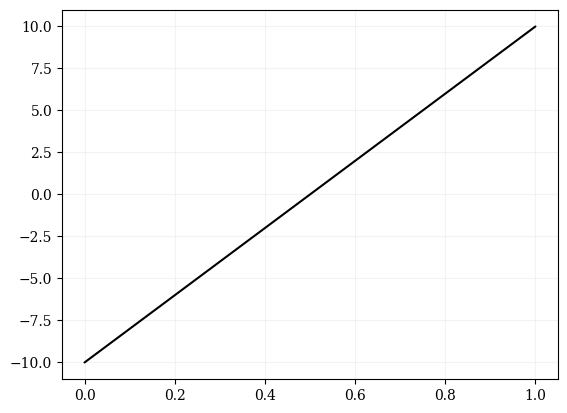

In [24]:
test = holo.librarian.lib_tools.PD_Uniform("test", -10.0, 10.0)
assert test(0.5) == 0.0
assert test(0.0) == -10.0
assert test(1.0) == +10.0

xx = np.linspace(0.0, 1.0, 100)
yy = test(xx)
plt.plot(xx, yy, 'k-')
plt.show()

### Normal (`PD_Normal`)

0.0


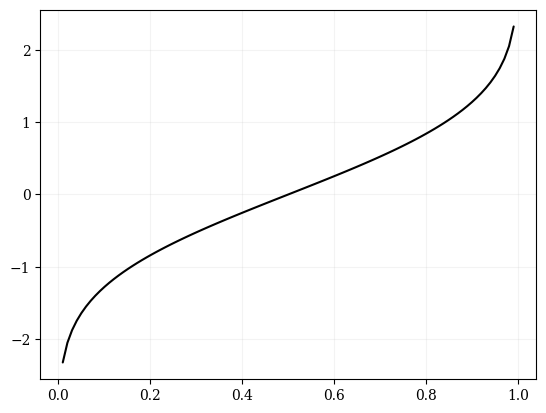

In [23]:
test = holo.librarian.lib_tools.PD_Normal("test", 0.0, 1.0)
val = test(0.5)
print(val)
assert test(0.5) == 0.0

xx = np.linspace(0.0, 1.0, 100)
yy = test(xx)
plt.plot(xx, yy, 'k-')
plt.show()

### LinLog (`PD_Lin_Log`)

[1.e-02 1.e+02]


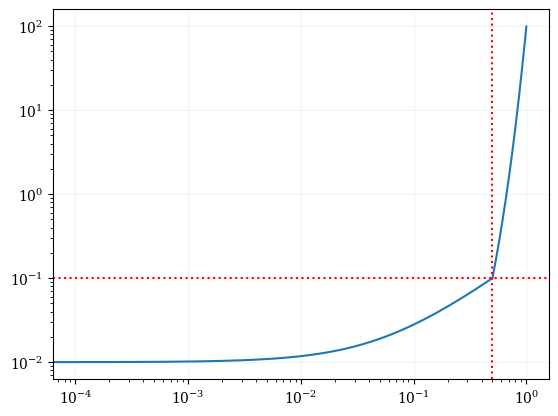

In [22]:
test = holo.librarian.lib_tools.PD_Lin_Log("test", 0.01, 100.0, 0.1, 0.5)
xx = np.linspace(0.0, 1.0, 10000)
yy = test(xx)
print(utils.minmax(yy))
plt.loglog(xx, yy)
ax = plt.gca()
ax.axhline(test._crit, color='r', ls=':')
ax.axvline(test._lofrac, color='r', ls=':')
plt.show()

Change the fraction of population below/above cutoff

target:0.20, result:0.1991 0.01
target:0.50, result:0.4904 0.01
target:0.80, result:0.8009 0.01


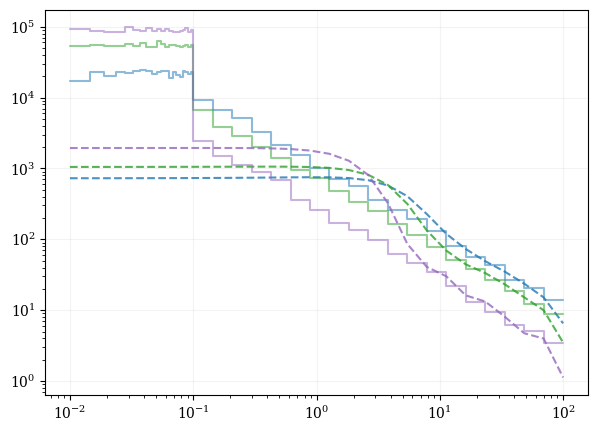

In [21]:
NUM = int(1e4)
crit = 0.1

BINS = 20
e1 = np.linspace(0.01, crit, BINS, endpoint=False)
e2 = np.logspace(*np.log10([crit, 100.0]), BINS)
edges = np.concatenate([e1, e2])

fig, ax = plot.figax(scale='log')
for frac in [0.2, 0.5, 0.8]:
    test = holo.librarian.lib_tools.PD_Lin_Log("test", 0.01, 100.0, crit, frac)
    xx = test(np.random.uniform(0.0, 1.0, size=NUM))
    kale.dist1d(xx, ax=ax, edges=edges, density=True, probability=False)
    obs_frac = np.count_nonzero(xx < crit) / xx.size
    print(f"target:{frac:.2f}, result:{obs_frac:.4f}", 1.0/np.sqrt(NUM))
    assert np.isclose(frac, obs_frac, atol=2.0/np.sqrt(NUM))

plt.show()

Change the location of the cutoff

target:0.50, result:0.4985 0.01
target:0.50, result:0.5026 0.01
target:0.50, result:0.5021 0.01


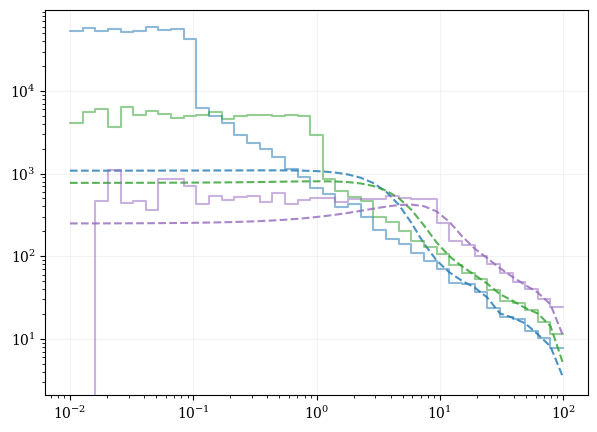

In [20]:
NUM = int(1e4)
frac = 0.5

BINS = 20
edges = np.logspace(*np.log10([0.01, 100.0]), 2*BINS)

fig, ax = plot.figax(scale='log')
for crit in [0.1, 1.0, 10.0]:
    test = holo.librarian.lib_tools.PD_Lin_Log("test", 0.01, 100.0, crit, frac)
    xx = test(np.random.uniform(0.0, 1.0, size=NUM))
    kale.dist1d(xx, ax=ax, edges=edges, density=True, probability=False)
    obs_frac = np.count_nonzero(xx < crit) / xx.size
    print(f"target:{frac:.2f}, result:{obs_frac:.4f}", 1.0/np.sqrt(NUM))
    assert np.isclose(frac, obs_frac, atol=2.0/np.sqrt(NUM))

plt.show()

### LogLin (`PD_Log_Lin`)

[1.e-02 1.e+02]


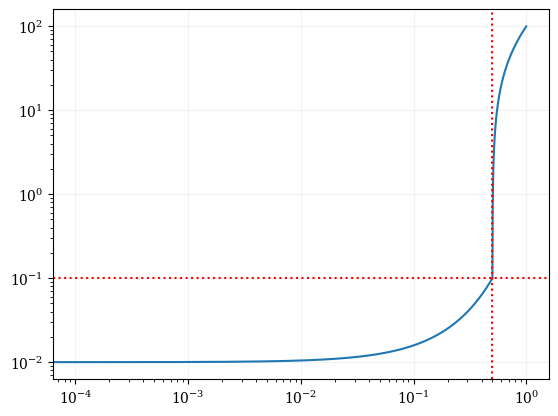

In [17]:
test = holo.librarian.lib_tools.PD_Log_Lin("test", 0.01, 100.0, 0.1, 0.5)
xx = np.linspace(0.0, 1.0, 10000)
yy = test(xx)
print(utils.minmax(yy))
plt.loglog(xx, yy)
ax = plt.gca()
ax.axhline(test._crit, color='r', ls=':')
ax.axvline(test._lofrac, color='r', ls=':')
plt.show()

Change the fraction of population below/above cutoff

target:0.20, result:0.1956 0.007071067811865475
target:0.50, result:0.5091 0.007071067811865475
target:0.80, result:0.7955 0.007071067811865475


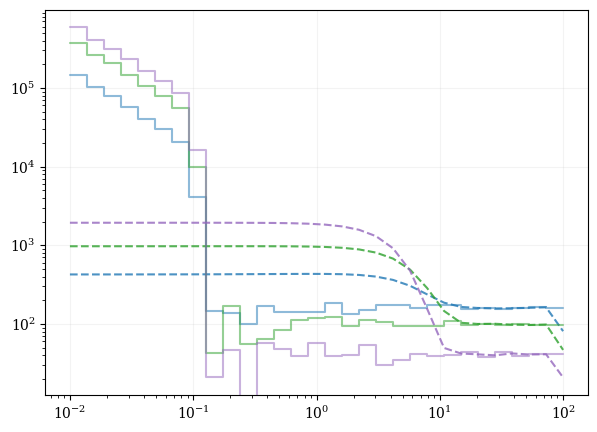

In [18]:
NUM = int(2e4)
crit = 0.1

BINS = 30
edges = np.logspace(*np.log10([0.01, 100.0]), BINS)

fig, ax = plot.figax(scale='log')
for frac in [0.2, 0.5, 0.8]:
    test = holo.librarian.lib_tools.PD_Log_Lin("test", 0.01, 100.0, crit, frac)
    xx = test(np.random.uniform(0.0, 1.0, size=NUM))
    kale.dist1d(xx, ax=ax, edges=edges, density=True, probability=False)
    obs_frac = np.count_nonzero(xx < crit) / xx.size
    print(f"target:{frac:.2f}, result:{obs_frac:.4f}", 1.0/np.sqrt(NUM))
    assert np.isclose(frac, obs_frac, atol=2.0/np.sqrt(NUM))

plt.show()

Change the location of the cutoff

target:0.50, result:0.5009 0.007071067811865475
target:0.50, result:0.4951 0.007071067811865475
target:0.50, result:0.4954 0.007071067811865475


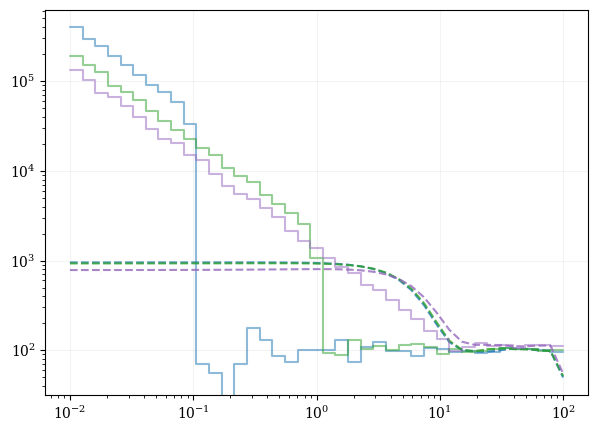

In [19]:
NUM = int(2e4)
frac = 0.5

BINS = 20

edges = np.logspace(*np.log10([0.01, 100.0]), 2*BINS)

fig, ax = plot.figax(scale='log')
for crit in [0.1, 1.0, 10.0]:
    test = holo.librarian.lib_tools.PD_Log_Lin("test", 0.01, 100.0, crit, frac)
    xx = test(np.random.uniform(0.0, 1.0, size=NUM))
    kale.dist1d(xx, ax=ax, edges=edges, density=True, probability=False)
    obs_frac = np.count_nonzero(xx < crit) / xx.size
    print(f"target:{frac:.2f}, result:{obs_frac:.4f}", 1.0/np.sqrt(NUM))
    assert np.isclose(frac, obs_frac, atol=2.0/np.sqrt(NUM))

plt.show()

### Piecewise Uniform in Mass (`PD_Piecewise_Uniform_Mass`)

[-0.9962556  6.9869381]


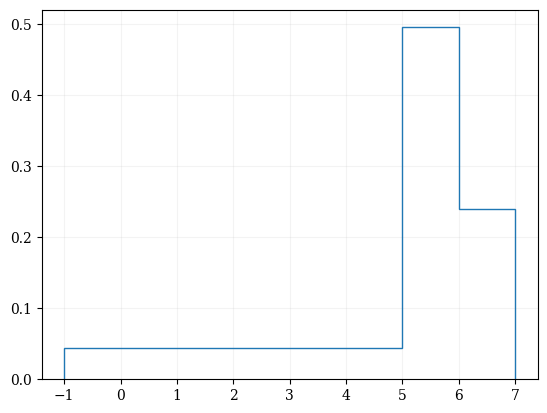

In [15]:
edges = [-1.0, 5.0, 6.0, 7.0]
amps = [1.0, 2.0, 1.0]
test = holodeck.librarian.lib_tools.PD_Piecewise_Uniform_Mass("test", edges, amps)

xx = np.random.uniform(size=1000)
xx = np.sort(xx)
yy = test(xx)
print(utils.minmax(yy))
x, y, _ = plt.hist(yy, histtype='step', density=True, bins=edges)
ax = plt.gca()
plt.show()

[-0.99545033  7.49568179]


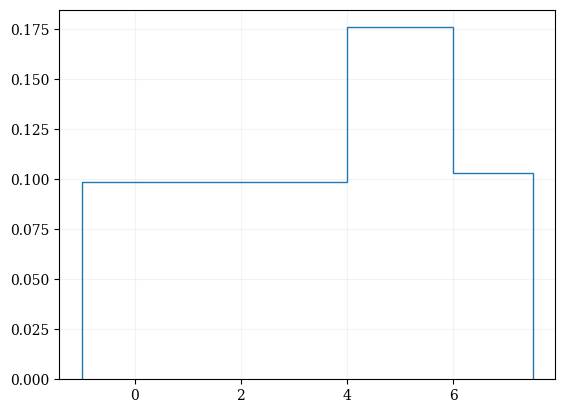

In [16]:
edges = [-1.0, 4.0, 6.0, 7.5]
test = holodeck.librarian.lib_tools.PD_Piecewise_Uniform_Density("test", edges, [1.0, 2.0, 1.0])

xx = np.random.uniform(size=1000)
xx = np.sort(xx)
yy = test(xx)
print(utils.minmax(yy))
x, y, _ = plt.hist(yy, histtype='step', density=True, bins=edges)
ax = plt.gca()
plt.show()

### Piecewise Uniform in Density (`PD_Piecewise_Uniform_Density`)

[ 0.10026472 10.99940146]


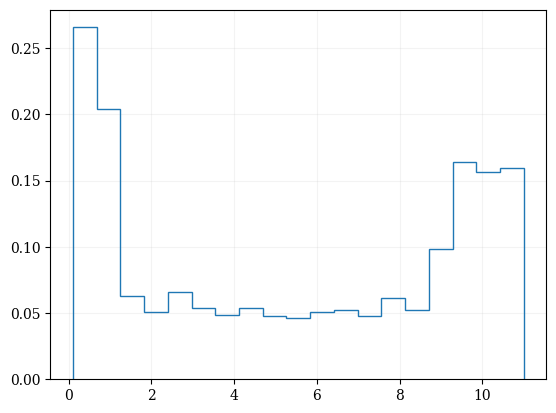

In [13]:
edges = [0.1, 1.0, 9.0, 11.0]
test = holodeck.librarian.lib_tools.PD_Piecewise_Uniform_Density("test", edges, [2.5, 0.5, 1.5])

xx = np.random.uniform(size=2000)
xx = np.sort(xx)
yy = test(xx)
print(utils.minmax(yy))
ax = plt.gca()
scale = 'log'
scale = 'linear'
ax.set(xscale=scale)
xx = kale.utils.spacing(edges, scale, num=20)
ax.hist(yy, histtype='step', density=True, bins=xx)
# tw = ax.twinx()
# tw.hist(yy, histtype='step', density=True, bins=30)
plt.show()

[7.50122215 9.49820667]
[7.50122215 7.60632659 7.71143104 7.81653549 7.92163994 8.02674439
 8.13184884 8.23695329 8.34205774 8.44716218 8.55226663 8.65737108
 8.76247553 8.86757998 8.97268443 9.07778888 9.18289333 9.28799777
 9.39310222 9.49820667]


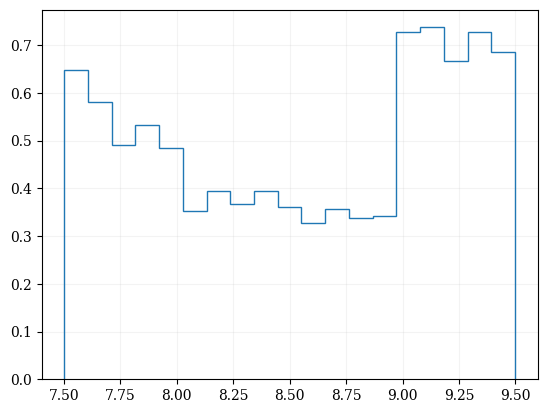

In [12]:
test = holodeck.librarian.lib_tools.PD_Piecewise_Uniform_Density(
    "test", [7.5, 8.0, 9.0, 9.5], [1.5, 1.0, 2.0]
)

xx = np.random.uniform(size=2000)
xx = np.sort(xx)
yy = test(xx)
print(utils.minmax(yy))
ax = plt.gca()
scale = 'log'
scale = 'linear'
ax.set(xscale=scale)
xx = kale.utils.spacing(yy, scale, num=20)
print(xx)
ax.hist(yy, histtype='step', density=True, bins=xx)
# tw = ax.twinx()
# tw.hist(yy, histtype='step', density=True, bins=30)
plt.show()

### Multivariate Normal Distribution (`PD_MVNormal`)

Median evaluation: [0. 0.]


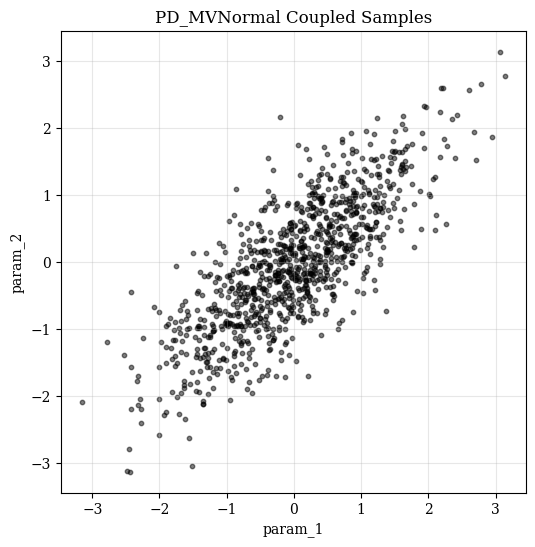

In [11]:
# Define a 2D Multivariate Normal distribution
# We provide a mean vector and a covariance matrix
mean = [0.0, 0.0]
cov = [[1.0, 0.8],   # Strong positive correlation
       [0.8, 1.0]]

test = holo.librarian.lib_tools.PD_MVNormal(("param_1", "param_2"), mean, cov)

# Check the median (0.5 for both uniform variables should return the mean)
# Note: PD_MVNormal expects a 2D array of shape (n_samples, n_dims)
val = test([[0.5, 0.5]])
print("Median evaluation:", val[0])
assert np.allclose(val[0], mean)

# Draw 1000 uniform 2D samples and transform them
NUM = 1000
xx = np.random.uniform(0.0, 1.0, size=(NUM, 2))
yy = test(xx)

# Plot the resulting correlated parameters
plt.figure(figsize=(6, 6))
plt.scatter(yy[:, 0], yy[:, 1], alpha=0.5, s=10, c='k')
plt.xlabel('param_1')
plt.ylabel('param_2')
plt.title('PD_MVNormal Coupled Samples')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()
